In [12]:
import scanpy as sc

adata_path = '/HDD1/xueweizhi/spvelo_data/simulate/simulate_dyngen/standard/general/dataset.h5ad'
adata = sc.read_h5ad(adata_path)
adata

AnnData object with n_obs × n_vars = 3000 × 435
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster'
    uns: 'coord_star', 'progress_colors'
    obsm: 'X_coord', 'dimred', 'spatial'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts', 'spliced', 'unspliced'

In [13]:
import numpy as np

n_batches = 2
adatas = []
for i in range(n_batches):
    adata_i = adata.copy()
    adata_i.obs['batch'] = str(i)
    noise = np.abs(np.random.normal(1, 0.5, size=adata_i.X.shape[1]))
    adata_i.var['noise'] = noise
    adata_i.X = adata.X.multiply(noise)
    adata_i.X = np.round(adata_i.X)
    adata_i.layers['spliced'] = adata_i.layers['spliced'].multiply(noise)
    adata_i.layers['spliced'] = np.round(adata_i.layers['spliced'])
    adata_i.layers['unspliced'] = adata_i.X - adata_i.layers['spliced']
    adatas.append(adata_i)
adata_with_batch = sc.concat(adatas, index_unique='-')
adata_with_batch

AnnData object with n_obs × n_vars = 6000 × 435
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch'
    obsm: 'X_coord', 'dimred', 'spatial'
    layers: 'counts_protein', 'counts_spliced', 'counts_unspliced', 'logcounts', 'spliced', 'unspliced'

In [14]:
save_dir = '/HDD1/xueweizhi/velocity_benchmark_data/batch_simu'
import os
os.makedirs(save_dir, exist_ok=True)
adata_with_batch.write_h5ad(f'{save_dir}/dataset.h5ad')

In [14]:
for adata_i in adatas:
    adata_i.X = adata_i.X.tocsr()
    sc.pp.normalize_total(adata_i)
    sc.pp.log1p(adata_i)
    sc.pp.highly_variable_genes(adata_i, flavor='seurat', n_top_genes=2000)

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future def

In [15]:
import scanorama

adatas_corr = scanorama.correct_scanpy(adatas)
adatas_corr

Found 435 genes among all datasets
[[0.    0.993]
 [0.    0.   ]]
Processing datasets (0, 1)


[AnnData object with n_obs × n_vars = 3000 × 435
     obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch'
     var: 'noise', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'coord_star', 'progress_colors', 'log1p', 'hvg'
     obsm: 'X_coord', 'dimred', 'spatial',
 AnnData object with n_obs × n_vars = 3000 × 435
     obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch'
     var: 'noise', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'coord_star', 'progress_colors', 'log1p', 'hvg'
     obsm: 'X_coord', 'dimred', 'spatial']

In [20]:
corr_adata = sc.concat(adatas_corr)
corr_adata

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 6000 × 435
    obs: 'step_ix', 'simulation_i', 'sim_time', 'from', 'to', 'percentage', 'progress', 'direction', 'rho', 'group', 'parent', 'x', 'y', 'Cluster', 'batch'
    obsm: 'X_coord', 'dimred', 'spatial'

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to a

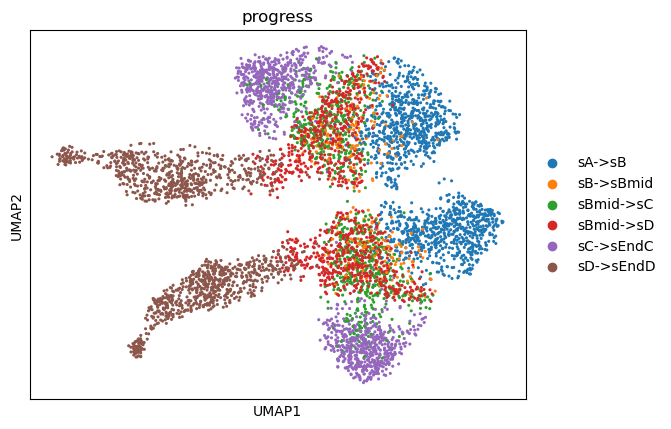

In [21]:
sc.pp.highly_variable_genes(adata_with_batch, n_top_genes=2000)
sc.pp.pca(adata_with_batch)
sc.pp.neighbors(adata_with_batch)
sc.tl.umap(adata_with_batch)
sc.pl.umap(adata_with_batch, color='progress')

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:226: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby("mean_bin")["dispersions"]
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:279: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  warnings.warn(
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to a

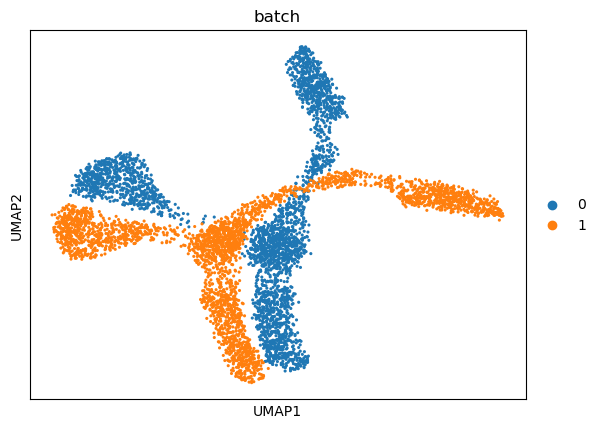

In [15]:
sc.pp.normalize_per_cell(adata_with_batch, counts_per_cell_after=1e4)
sc.pp.log1p(adata_with_batch)
sc.pp.highly_variable_genes(adata_with_batch, n_top_genes=2000)
sc.pp.pca(adata_with_batch)
sc.pp.neighbors(adata_with_batch)
sc.tl.umap(adata_with_batch)
sc.pl.umap(adata_with_batch, color='batch')

/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1234: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/xueweizhi/miniconda3/envs/velo_env_stt/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


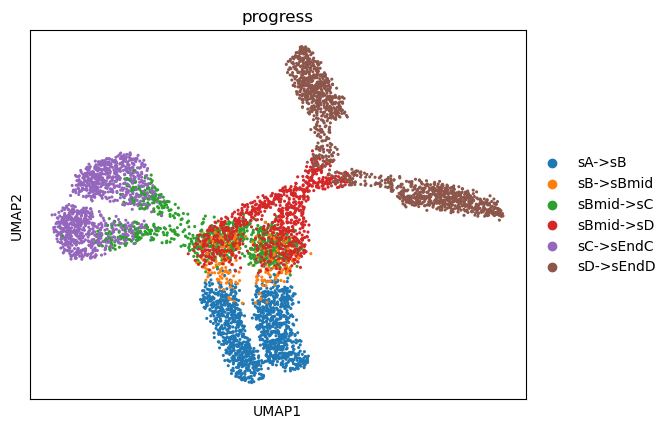

In [16]:
sc.pl.umap(adata_with_batch, color='progress')